In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df= pd.read_csv("D:\Jupyter_Notebooks\Dataset .csv")

#### Preview of the Dataset


In [4]:
df.head(5)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


#### Dataset Dimensions


In [5]:
df.shape

(9551, 21)

#### Structure and Data Types of the Dataset


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

#### Missing Values Analysis


In [7]:
df.isnull().sum()


Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

#### Handling Missing Values in Cuisines Column

In [8]:
from sklearn.impute import SimpleImputer
si= SimpleImputer(strategy="most_frequent")
df[['Cuisines']] = si.fit_transform(df[['Cuisines']])


#### Overall Missing Data Percentage

In [9]:
(df.isnull().sum().sum()) / (df.shape[0]*df.shape[1])*100

np.float64(0.0)

# Level-1: Exploratory Data Analysis:
### In this section, basic trends and customer preferences are analyzed.


#### Task 1: Top Cuisines

In [10]:
# Find Top 3 Cuisines:
top_cuisines = df['Cuisines'].str.split(', ').explode().value_counts().head(3)
top_cuisines


Cuisines
North Indian    3969
Chinese         2735
Fast Food       1986
Name: count, dtype: int64

In [11]:
# Percentage of Top Cuisines:
top_cuisines_percentage = (top_cuisines / len(df)) * 100
top_cuisines_percentage

Cuisines
North Indian    41.555858
Chinese         28.635745
Fast Food       20.793634
Name: count, dtype: float64

#### Task 2: City Analysis

In [12]:
# City with Highest Number of Restaurants:
city_counts = df['City'].value_counts()
city_counts.head()


City
New Delhi    5473
Gurgaon      1118
Noida        1080
Faridabad     251
Ghaziabad      25
Name: count, dtype: int64

In [13]:
# Average Rating per City:
avg_rating_city = df.groupby('City')['Aggregate rating'].mean().sort_values(ascending=False)
avg_rating_city.head()


City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
Name: Aggregate rating, dtype: float64

#### Task 3: Price Range Distribution

In [14]:
# Price Range Count:
price_counts = df['Price range'].value_counts().sort_index()
price_counts


Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64

In [16]:
# Price Range Percentage:
price_percentage = (price_counts / len(df)) * 100
price_percentage


Price range
1    46.529159
2    32.593446
3    14.741912
4     6.135483
Name: count, dtype: float64

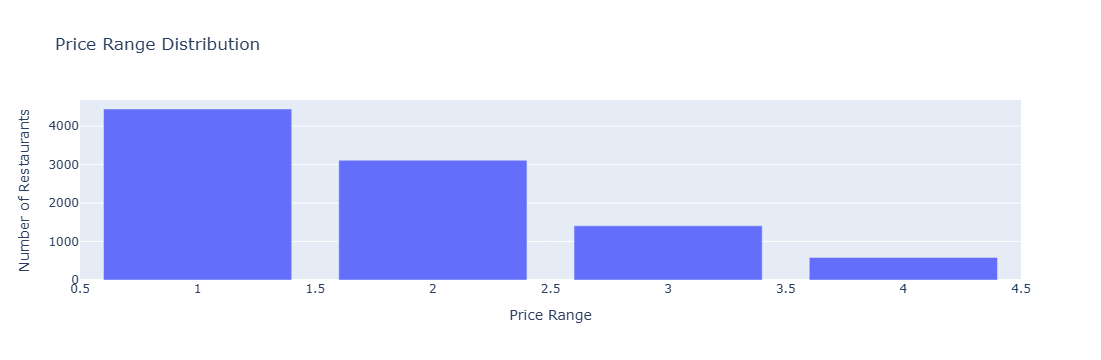

In [67]:
# Bar Chart – Price Range:
import plotly.express as px
fig = px.bar( x=price_counts.index, y=price_counts.values,
    labels={"x": "Price Range", "y": "Number of Restaurants"},
    title="Price Range Distribution")
fig.show()

#### Task 4: Online Delivery

In [24]:
# Percentage of Online Delivery:
online_delivery_counts = df['Has Online delivery'].value_counts()
online_delivery_counts

Has Online delivery
No     7100
Yes    2451
Name: count, dtype: int64

In [25]:
online_delivery_percentage = (online_delivery_counts / len(df)) * 100
online_delivery_percentage

Has Online delivery
No     74.337766
Yes    25.662234
Name: count, dtype: float64

In [26]:
# Compare Average Ratings:
delivery_rating = df.groupby('Has Online delivery')['Aggregate rating'].mean()
delivery_rating

Has Online delivery
No     2.465296
Yes    3.248837
Name: Aggregate rating, dtype: float64

In [ ]:
# Rating Comparison Bar Chart:
delivery_rating.plot(kind='bar')
plt.xlabel("Online Delivery")
plt.ylabel("Average Rating")
plt.title("Online Delivery vs Average Rating")
plt.show()

# Level 2 – Pattern & Relationship Analysis:
### This section focuses on identifying patterns, combinations, and geographic insights.

#### Task 1: Geographic Analysis

In [28]:
# Latitude & Longitude Check:
df[['Latitude', 'Longitude']].head()

,Latitude,Longitude
0,14.565443,121.027535
1,14.553708,121.014101
2,14.581404,121.056831
3,14.585318,121.056475
4,14.584450,121.057508


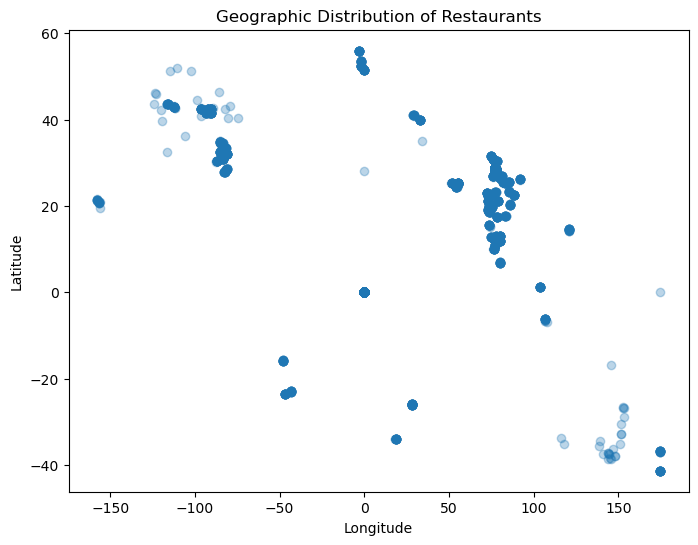

In [29]:
# Scatter Plot – Restaurant Locations:
plt.figure(figsize=(8,6))
plt.scatter(df['Longitude'], df['Latitude'], alpha=0.3)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Distribution of Restaurants")
plt.show()

In [31]:
# City-wise Restaurant Count:
city_location_count = df['City'].value_counts().head(10)
city_location_count

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Lucknow           21
Ahmedabad         21
Amritsar          21
Guwahati          21
Name: count, dtype: int64

#### Task 2: Restaurant Chains

In [32]:
# Identify Restaurant Chains: 
restaurant_counts = df['Restaurant Name'].value_counts()
chains = restaurant_counts[restaurant_counts > 1]
chains.head()

Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Name: count, dtype: int64

In [33]:
# Top Restaurant Chains: 
top_chains = chains.head(10)
top_chains

Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64

In [34]:
# Average Rating of Restaurant Chains:
chain_ratings = df[df['Restaurant Name'].isin(top_chains.index)]
chain_ratings.groupby('Restaurant Name')['Aggregate rating'].mean().sort_values(ascending=False)

Restaurant Name
Barbeque Nation     4.353846
McDonald's          3.339583
Pizza Hut           3.320000
Subway              2.907937
Keventers           2.870588
Domino's Pizza      2.740506
Giani               2.689655
Green Chick Chop    2.672549
Cafe Coffee Day     2.419277
Baskin Robbins      1.860714
Name: Aggregate rating, dtype: float64

In [36]:
# Votes Analysis for Chains:
chain_votes = df[df['Restaurant Name'].isin(top_chains.index)]
chain_votes.groupby('Restaurant Name')['Votes'].mean().sort_values(ascending=False)

Restaurant Name
Barbeque Nation     1082.384615
Pizza Hut            165.366667
McDonald's           110.229167
Subway                97.206349
Domino's Pizza        84.088608
Keventers             37.147059
Giani                 29.448276
Cafe Coffee Day       29.253012
Green Chick Chop      18.901961
Baskin Robbins        15.285714
Name: Votes, dtype: float64

# Level 3 – Advanced Business Insights:
### This section contains advanced analysis aimed at business decision-making.


#### Task 1: Restaurant Reviews Analysis

In [38]:
# Rating Text Distribution:
df['Rating text'].value_counts()

Rating text
Average      3737
Not rated    2148
Good         2100
Very Good    1079
Excellent     301
Poor          186
Name: count, dtype: int64

In [42]:
# Positive vs Negative Ratings:
positive_ratings = df[df['Aggregate rating'] >= 4]
negative_ratings = df[df['Aggregate rating'] <= 2]
print("Positive Ratings:",len(positive_ratings))
print("Negative Ratings:", len(negative_ratings))

Positive Ratings: 1380
Negative Ratings: 2158


In [46]:
# Average Votes – Positive vs Negative:
print("Positive Average Ratings:", positive_ratings['Votes'].mean())
print("Negative Average Ratings:", negative_ratings['Votes'].mean())

Positive Average Ratings: 592.7231884057971
Negative Average Ratings: 1.5342910101946245


In [47]:
# Review Length Approximation:
df['Rating_length'] = df['Rating text'].astype(str).apply(len)
df[['Rating text', 'Rating_length']].head()

,Rating text,Rating_length
0,Excellent,9
1,Excellent,9
2,Very Good,9
3,Excellent,9
4,Excellent,9


#### Task 2: Votes Analysis

In [48]:
# Restaurants with Highest Votes:
df[['Restaurant Name', 'Votes']].sort_values(by='Votes', ascending=False).head(10)

,Restaurant Name,Votes
728,Toit,10934
735,Truffles,9667
3994,Hauz Khas Social,7931
2412,Peter Cat,7574
739,AB's - Absolute Barbecues,6907
2414,Barbeque Nation,5966
743,Big Brewsky,5705
2307,AB's - Absolute Barbecues,5434
736,The Black Pearl,5385
2411,BarBQ,5288


In [49]:
# Restaurants with Lowest Votes:
df[['Restaurant Name', 'Votes']].sort_values(by='Votes').head(10)

,Restaurant Name,Votes
1173,Aha Bites,0
1172,Achoos Food Corner,0
8558,Food Town,0
6165,Zaika Restaurant,0
6164,Smily Cakes,0
6161,Roll Junction,0
1178,Gopi Sweets & Caters,0
1186,Tanishk Gourmet Indian,0
1185,Solty Hotel,0
1183,OMG Tiffinz,0


In [50]:
# Correlation Between Votes and Rating:
correlation = df['Votes'].corr(df['Aggregate rating'])
correlation

np.float64(0.3136905841954117)

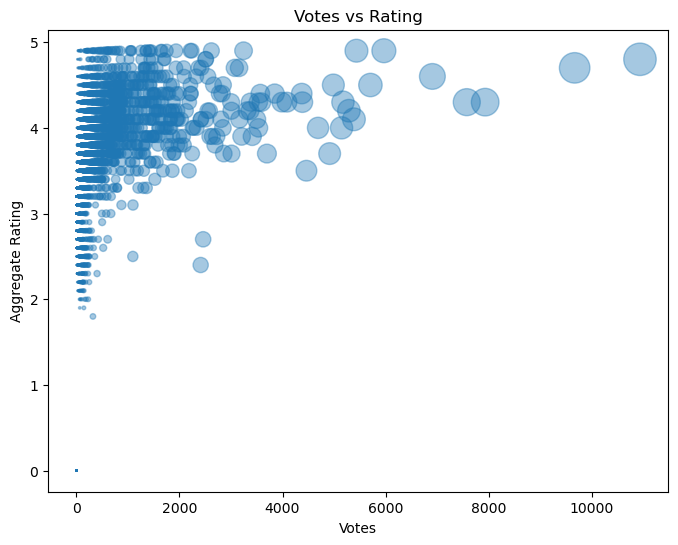

In [61]:
# Scatter Plot – Votes vs Rating:
plt.figure(figsize=(8,6))
plt.scatter(df['Votes'], df['Aggregate rating'], s=df['Votes']*0.05, alpha=0.4)
plt.xlabel("Votes")
plt.ylabel("Aggregate Rating")
plt.title("Votes vs Rating")
plt.show()

#### Task 3: Price Range vs Services

In [52]:
# Price Range vs Online Delivery:
pd.crosstab(df['Price range'], df['Has Online delivery'])

Has Online delivery,No,Yes
Price range,,
1,3743,701
2,1827,1286
3,997,411
4,533,53


In [53]:
# Price Range vs Table Booking:
pd.crosstab(df['Price range'], df['Has Table booking'])

Has Table booking,No,Yes
Price range,,
1,4443,1
2,2874,239
3,764,644
4,312,274


In [54]:
# Average Rating by Price Range:
df.groupby('Price range')['Aggregate rating'].mean()

Price range
1    1.999887
2    2.941054
3    3.683381
4    3.817918
Name: Aggregate rating, dtype: float64

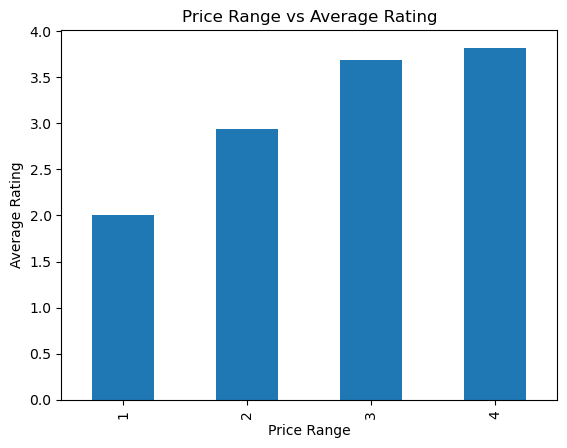

In [56]:
# Visualization – Price Range vs Rating:
df.groupby('Price range')['Aggregate rating'].mean().plot(kind='bar')
plt.xlabel("Price Range")
plt.ylabel("Average Rating")
plt.title("Price Range vs Average Rating")
plt.show()